# STQD6324 Data Management — Assignment 2
## MovieLens 100k Data Pipeline: Apache Spark & Cassandra

**Student Information**
| Field | Detail |
|---|---|
| P162501 | SOFIA ANNISA BINTI JAIRI |
| Dataset | MovieLens 100k (`u.data`, `u.user`, `u.item`) |

**Environment Versions**
| Component | Version |
|---|---|
| Python | 3.12 |
| Apache Spark (PySpark) | 4.0.2 |
| Java | OpenJDK 17 (required for PySpark 4.x) |
| Cassandra | 4.1.3 |
| cassandra-driver | 3.28+ |
| pandas | 2.x |
| matplotlib | 3.x |


**Notebook Structure**
1. Milestone 1 — Environment Setup, Library Imports & Cassandra Start
2. Milestone 2 — Data Ingestion: Files → RDDs → DataFrames
3. Milestone 3 — Data Cleaning & Preprocessing
4. Milestone 4 — Exploratory Data Analysis with Spark SQL
5. Milestone 5 — Analytical Tasks (i – v)
6. Milestone 6 — Cassandra Integration: Write & Validate


---
## Milestone 1: Environment Setup, Library Imports & Cassandra Start

**Requirement 1** — Install and import all required Python libraries for Apache Spark and Cassandra integration.

### PySpark 4.0 needs Java 17
PySpark 4.0+ compiles its JARs to class file version 61.0 (Java 17). Running it under Java 11 (class version 55.0) throws `UnsupportedClassVersionError` which surfaces as `JAVA_GATEWAY_EXITED`. The cell below kills any stale Java processes, forces Java 17, then verifies before Spark starts.


In [ ]:
# ── Cell 1: Kill stale Java, install packages ─────────────────────────────
# Run this first — always — before any Spark code.
!pkill -f java 2>/dev/null; echo "stale processes cleared"
!pip install pyspark cassandra-driver pandas matplotlib --quiet


^C


In [ ]:
# ── Cell 2: Set Java 17 (MUST run before importing PySpark) ───────────────
import os, subprocess

# PySpark 4.0 requires Java 17; Java 11 causes JAVA_GATEWAY_EXITED
JAVA17 = "/usr/lib/jvm/java-1.17.0-openjdk-amd64"
os.environ["JAVA_HOME"] = JAVA17
os.environ["PATH"]      = JAVA17 + "/bin:" + os.environ.get("PATH", "")

# Verify — stderr is where java -version writes
r = subprocess.run(["java", "-version"], capture_output=True, text=True)
print(r.stderr.strip())
print("JAVA_HOME:", os.environ["JAVA_HOME"])


openjdk version "17.0.19" 2026-04-21
OpenJDK Runtime Environment (build 17.0.19+10-1-22.04.2-Ubuntu)
OpenJDK 64-Bit Server VM (build 17.0.19+10-1-22.04.2-Ubuntu, mixed mode, sharing)
JAVA_HOME: /usr/lib/jvm/java-1.17.0-openjdk-amd64


In [ ]:
# ── Cell 3: Import all libraries ──────────────────────────────────────────
import os, time, subprocess

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, avg, count, desc, explode, lit, when,
    round as spark_round, rank
)
from pyspark.sql.types import (
    StructType, StructField, IntegerType, StringType, FloatType
)
from pyspark.sql.window import Window

# Cassandra Python driver
from cassandra.cluster import Cluster
from cassandra.policies import RoundRobinPolicy

# Visualisation
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['figure.figsize'] = (10, 5)

print(" All libraries imported successfully.")


 All libraries imported successfully.


### 1.1 Start Apache Cassandra Service

Cassandra 4.1.x runs on Java 11. Start it with a dedicated `JAVA_HOME` override so it does **not** inherit the Java 17 set for Spark. The two can coexist because they run as separate processes.

> Skip this section if Cassandra is already running in machine.


In [ ]:
# ── Download & start Cassandra 4.1.3 ──────────────────────────────────────
CASS_VER = "4.1.3"
CASS_TAR = f"apache-cassandra-{CASS_VER}-bin.tar.gz"
CASS_URL = f"https://archive.apache.org/dist/cassandra/{CASS_VER}/{CASS_TAR}"
CASS_DIR = f"apache-cassandra-{CASS_VER}"

# Cassandra 4.x needs Java 11
print("Installing Java 11 for Cassandra...")
os.system("apt-get install -y openjdk-11-jdk-headless -qq > /dev/null 2>&1")
JAVA11 = "/usr/lib/jvm/java-1.11.0-openjdk-amd64"

if not os.path.isdir(CASS_DIR):
    print(f"Downloading Cassandra {CASS_VER}...")
    os.system(f"wget -q {CASS_URL}")
    os.system(f"tar xzf {CASS_TAR}")
    print("Extraction complete.")
else:
    print(f"Cassandra {CASS_VER} already extracted.")

# Launch with Java 11 explicitly, keeping our env Java 17 for Spark
env_cass = {**os.environ, "JAVA_HOME": JAVA11,
            "PATH": JAVA11 + "/bin:" + os.environ.get("PATH", "")}
subprocess.Popen(
    [f"{CASS_DIR}/bin/cassandra", "-R"],
    env=env_cass,
    stdout=subprocess.DEVNULL,
    stderr=open("/tmp/cassandra.log", "w")
)
print("Cassandra starting — waiting 60 seconds for initialisation...")
time.sleep(60)
print("Done.")


Installing Java 11 for Cassandra...
Cassandra 4.1.3 already extracted.
Cassandra starting — waiting 60 seconds for initialisation...
Done.


### 1.2 Verify Cassandra is Reachable


In [ ]:
# ── Verify Cassandra with retry ───────────────────────────────────────────
for attempt in range(1, 6):
    try:
        _c = Cluster(['127.0.0.1'], load_balancing_policy=RoundRobinPolicy(),
                     connect_timeout=10)
        _s = _c.connect()
        print(f" Cassandra is UP (attempt {attempt})")
        _c.shutdown()
        break
    except Exception as e:
        print(f"Attempt {attempt}/5: {e}")
        if attempt < 5:
            time.sleep(15)
        else:
            print("⚠️  Cassandra did not start. Check /tmp/cassandra.log")


/tmp/ipykernel_26670/803893726.py:4: DeprecationWarning: Legacy execution parameters will be removed in 4.0. Consider using execution profiles.
  _c = Cluster(['127.0.0.1'], load_balancing_policy=RoundRobinPolicy(),


 Cassandra is UP (attempt 1)


### 1.3 Initialise Spark Session

Start Spark **without** the `spark.jars.packages` connector option.  

**Why?** In Colab, `spark.jars.packages` triggers a Maven download at startup — if the network blocks Maven (or the download times out), the Java gateway exits before sending its port number, producing the `JAVA_GATEWAY_EXITED` error. Instead write to Cassandra via the Python `cassandra-driver` directly, which is simpler and more reliable in notebook environments.


In [ ]:
# ── Initialise SparkSession ────────────────────────────────────────────────
# Stop any existing session first
if 'spark' in globals() and spark is not None:
    try:
        spark.stop()
    except Exception:
        pass
    spark = None

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("STQD6324_Assignment2_MovieLens")
    .config("spark.driver.memory",      "2g")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.network.timeout",    "800s")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f" Spark Session ready  |  version: {spark.version}")
print(f"   App: {spark.sparkContext.appName}")


 Spark Session ready  |  version: 4.0.2
   App: STQD6324_Assignment2_MovieLens


---
## Milestone 2: Data Ingestion — Files → RDDs → DataFrames

**Requirements 2, 3 & 4** — Load the MovieLens dataset files into Spark, create RDD objects from the raw data, then transform the RDDs into Spark DataFrames.

### Dataset Overview
| File | Delimiter | Description |
|---|---|---|
| `u.data` | Tab (`\t`) | 100,000 ratings: user_id, movie_id, rating, timestamp |
| `u.user` | Pipe (`\|`) | 943 users: user_id, age, gender, occupation, zip_code |
| `u.item` | Pipe (`\|`) | 1,682 movies: movie_id, title, release_date, url, 19 genre flags |


In [ ]:
# ── Column definitions ────────────────────────────────────────────────────
data_cols = ['user_id', 'movie_id', 'rating', 'timestamp']

item_cols = [
    'movie_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL',
    'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film_Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci_Fi', 'Thriller', 'War', 'Western'
]

user_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

GENRE_COLS = item_cols[5:]   # 19 binary genre flag column names

print("Column definitions set.")
print(f"  Ratings : {data_cols}")
print(f"  Users   : {user_cols}")
print(f"  Genres  : {GENRE_COLS}")


Column definitions set.
  Ratings : ['user_id', 'movie_id', 'rating', 'timestamp']
  Users   : ['user_id', 'age', 'gender', 'occupation', 'zip_code']
  Genres  : ['unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film_Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci_Fi', 'Thriller', 'War', 'Western']


### 2.1 Set File Paths

The helper below tries the standard Colab upload path (`/content/`) first, then falls back to alternative locations. Upload `u.data`, `u.user`, and `u.item` to Colab session.

In [ ]:
# ── Resolve dataset file paths ────────────────────────────────────────────
def resolve_path(filename, candidates):
    """Return the first existing candidate path for the given filename."""
    for c in candidates:
        if os.path.exists(c):
            return c
    raise FileNotFoundError(
        f"Could not find {filename}. Upload it to /content/ in Colab. "
        f"Tried: {candidates}"
    )

DATA_PATH = resolve_path("u.data", ["/content/u.data", "u.data"])
USER_PATH = resolve_path("u.user", ["/content/u.user", "u.user"])
ITEM_PATH = resolve_path("u.item", ["/content/u.item", "u.item"])

print(f" u.data → {DATA_PATH}")
print(f" u.user → {USER_PATH}")
print(f" u.item → {ITEM_PATH}")


 u.data → /content/u.data
 u.user → /content/u.user
 u.item → /content/u.item


### 2.2 Load Files into RDDs

`SparkContext.textFile()` reads each file into a Resilient Distributed Dataset (RDD), where every element is one raw text line.


In [ ]:
# ── Load raw files into RDDs ──────────────────────────────────────────────
ratings_rdd = spark.sparkContext.textFile(DATA_PATH)
users_rdd   = spark.sparkContext.textFile(USER_PATH)
items_rdd   = spark.sparkContext.textFile(ITEM_PATH)

print(f"ratings_rdd  partitions : {ratings_rdd.getNumPartitions()}")
print(f"users_rdd    partitions : {users_rdd.getNumPartitions()}")
print(f"items_rdd    partitions : {items_rdd.getNumPartitions()}")
print()
print(f"Sample — ratings : {ratings_rdd.first()}")
print(f"Sample — users   : {users_rdd.first()}")
print(f"Sample — items   : {items_rdd.first()[:80]}...")


ratings_rdd  partitions : 2
users_rdd    partitions : 2
items_rdd    partitions : 2

Sample — ratings : 196	242	3	881250949
Sample — users   : 1|24|M|technician|85711
Sample — items   : 1|Toy Story (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Toy%20Story%20(...


### 2.3 Convert RDDs → Spark DataFrames

Each RDD is split on its delimiter, fields are cast to correct types, then converted to a Spark DataFrame with `.toDF()`. Malformed rows (wrong field count) are filtered before casting to avoid runtime errors.


In [ ]:
# ── Ratings DataFrame (u.data, tab-separated) ─────────────────────────────
ratings_df = (
    ratings_rdd
    .map(lambda line: line.split("\t"))
    .filter(lambda p: len(p) == 4)                    # drop malformed rows
    .map(lambda p: (int(p[0]), int(p[1]), int(p[2]), int(p[3])))
    .toDF(data_cols)
    .dropna()
)

print("ratings_df schema:")
ratings_df.printSchema()
ratings_df.show(5, truncate=False)
print(f"Total ratings: {ratings_df.count():,}")


ratings_df schema:
root
 |-- user_id: long (nullable = true)
 |-- movie_id: long (nullable = true)
 |-- rating: long (nullable = true)
 |-- timestamp: long (nullable = true)

+-------+--------+------+---------+
|user_id|movie_id|rating|timestamp|
+-------+--------+------+---------+
|196    |242     |3     |881250949|
|186    |302     |3     |891717742|
|22     |377     |1     |878887116|
|244    |51      |2     |880606923|
|166    |346     |1     |886397596|
+-------+--------+------+---------+
only showing top 5 rows
Total ratings: 100,000


In [ ]:
# ── Users DataFrame (u.user, pipe-separated) ──────────────────────────────
users_df = (
    users_rdd
    .map(lambda line: line.split("|"))
    .filter(lambda p: len(p) == 5)
    .map(lambda p: (int(p[0]), int(p[1]), p[2].strip(), p[3].strip(), p[4].strip()))
    .toDF(user_cols)
    .dropna()
)

print("users_df schema:")
users_df.printSchema()
users_df.show(5, truncate=False)
print(f"Total users: {users_df.count():,}")


users_df schema:
root
 |-- user_id: long (nullable = true)
 |-- age: long (nullable = true)
 |-- gender: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- zip_code: string (nullable = true)

+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|1      |24 |M     |technician|85711   |
|2      |53 |F     |other     |94043   |
|3      |23 |M     |writer    |32067   |
|4      |24 |M     |technician|43537   |
|5      |33 |F     |other     |15213   |
+-------+---+------+----------+--------+
only showing top 5 rows
Total users: 943


In [ ]:
# ── Items DataFrame (u.item, pipe-separated, 24 columns) ─────────────────
items_df = (
    items_rdd
    .map(lambda line: line.split("|"))
    .filter(lambda p: len(p) >= 24)                   # drop malformed rows
    .map(lambda p: (
        int(p[0]),          # movie_id
        p[1].strip(),       # movie_title
        p[2].strip(),       # release_date
        p[3].strip(),       # video_release_date
        p[4].strip(),       # IMDb_URL
        *[int(x) for x in p[5:24]]                   # 19 binary genre flags
    ))
    .toDF(item_cols)
    .dropna()
)

print("items_df schema:")
items_df.printSchema()
items_df.show(3, truncate=False)
print(f"Total movies: {items_df.count():,}")


items_df schema:
root
 |-- movie_id: long (nullable = true)
 |-- movie_title: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- video_release_date: string (nullable = true)
 |-- IMDb_URL: string (nullable = true)
 |-- unknown: long (nullable = true)
 |-- Action: long (nullable = true)
 |-- Adventure: long (nullable = true)
 |-- Animation: long (nullable = true)
 |-- Childrens: long (nullable = true)
 |-- Comedy: long (nullable = true)
 |-- Crime: long (nullable = true)
 |-- Documentary: long (nullable = true)
 |-- Drama: long (nullable = true)
 |-- Fantasy: long (nullable = true)
 |-- Film_Noir: long (nullable = true)
 |-- Horror: long (nullable = true)
 |-- Musical: long (nullable = true)
 |-- Mystery: long (nullable = true)
 |-- Romance: long (nullable = true)
 |-- Sci_Fi: long (nullable = true)
 |-- Thriller: long (nullable = true)
 |-- War: long (nullable = true)
 |-- Western: long (nullable = true)

+--------+-----------------+------------+-----------------

---
## Milestone 3: Data Cleaning & Preprocessing

**Requirement 5** — Perform appropriate data cleaning and preprocessing.

**Steps applied:**
- Malformed rows (wrong field count) are filtered during RDD parsing — before any type casting — so no `ValueError` can occur.
- `dropna()` removes any rows where a field is null after conversion.
- String fields (`gender`, `occupation`, `zip_code`) are `.strip()`-trimmed to remove surrounding whitespace.
- A derived `genres` list column is built from the 19 binary genre flags on `items_df`. This collapses `Action=1, Comedy=1, Drama=0 …` into `genres = ['Action', 'Comedy']`, which is essential for Task (iii).


In [ ]:
# ── Build 'genres' list column from the 19 binary flag columns ────────────
# F.when(col(g) == 1, lit(g)) returns the genre name if the flag is set,
# else None. F.filter(...) keeps only the non-null entries.
items_df = items_df.withColumn(
    "genres",
    F.filter(
        F.array(*[
            F.when(col(g) == 1, lit(g)).otherwise(lit(None))
            for g in GENRE_COLS
        ]),
        lambda x: x.isNotNull()
    )
)

print(" 'genres' list column created.")
items_df.select("movie_id", "movie_title", "genres").show(10, truncate=False)


 'genres' list column created.
+--------+----------------------------------------------------+------------------------------+
|movie_id|movie_title                                         |genres                        |
+--------+----------------------------------------------------+------------------------------+
|1       |Toy Story (1995)                                    |[Animation, Childrens, Comedy]|
|2       |GoldenEye (1995)                                    |[Action, Adventure, Thriller] |
|3       |Four Rooms (1995)                                   |[Thriller]                    |
|4       |Get Shorty (1995)                                   |[Action, Comedy, Drama]       |
|5       |Copycat (1995)                                      |[Crime, Drama, Thriller]      |
|6       |Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)|[Drama]                       |
|7       |Twelve Monkeys (1995)                               |[Drama, Sci_Fi]               |
|8       |Babe (199

In [ ]:
# ── Null check on all DataFrames ──────────────────────────────────────────
print("Null counts — ratings_df:")
ratings_df.select([F.count(F.when(col(c).isNull(), c)).alias(c)
                   for c in ratings_df.columns]).show()

print("Null counts — users_df:")
users_df.select([F.count(F.when(col(c).isNull(), c)).alias(c)
                 for c in users_df.columns]).show()

print("Null counts — items_df (key columns):")
items_df.select([F.count(F.when(col(c).isNull(), c)).alias(c)
                 for c in ["movie_id", "movie_title", "genres"]]).show()


Null counts — ratings_df:
+-------+--------+------+---------+
|user_id|movie_id|rating|timestamp|
+-------+--------+------+---------+
|      0|       0|     0|        0|
+-------+--------+------+---------+

Null counts — users_df:
+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|      0|  0|     0|         0|       0|
+-------+---+------+----------+--------+

Null counts — items_df (key columns):
+--------+-----------+------+
|movie_id|movie_title|genres|
+--------+-----------+------+
|       0|          0|     0|
+--------+-----------+------+



In [ ]:
# ── Dataset summary ───────────────────────────────────────────────────────
print(f"{'='*45}")
print(f"  Dataset Summary")
print(f"{'='*45}")
print(f"  Total ratings  : {ratings_df.count():>8,}")
print(f"  Total users    : {users_df.count():>8,}")
print(f"  Total movies   : {items_df.count():>8,}")
print(f"  Rating range   : "
      f"{ratings_df.agg(F.min('rating')).collect()[0][0]} – "
      f"{ratings_df.agg(F.max('rating')).collect()[0][0]}")
print(f"  Age range      : "
      f"{users_df.agg(F.min('age')).collect()[0][0]} – "
      f"{users_df.agg(F.max('age')).collect()[0][0]}")
print(f"{'='*45}")


  Dataset Summary
  Total ratings  :  100,000
  Total users    :      943
  Total movies   :    1,682
  Rating range   : 1 – 5
  Age range      : 7 – 73


---
## Milestone 4: Exploratory Data Analysis with Spark SQL

**Requirement 6** — Execute queries using Apache Spark SQL.

Register all DataFrames as temporary SQL views, which mix the DataFrame API and raw SQL freely throughout the rest of the notebook.


In [ ]:
# ── Register SQL views ────────────────────────────────────────────────────
ratings_df.createOrReplaceTempView("ratings")
users_df.createOrReplaceTempView("users")
items_df.createOrReplaceTempView("items")
print("SQL views registered: ratings, users, items")


SQL views registered: ratings, users, items


In [ ]:
# Most rated movies
print("Most rated movies (top 10):")
spark.sql("""
    SELECT i.movie_title, COUNT(*) AS rating_count
    FROM items i JOIN ratings r ON i.movie_id = r.movie_id
    GROUP BY i.movie_title
    ORDER BY rating_count DESC
""").show(10, truncate=False)


Most rated movies (top 10):
+-----------------------------+------------+
|movie_title                  |rating_count|
+-----------------------------+------------+
|Star Wars (1977)             |583         |
|Contact (1997)               |509         |
|Fargo (1996)                 |508         |
|Return of the Jedi (1983)    |507         |
|Liar Liar (1997)             |485         |
|English Patient, The (1996)  |481         |
|Scream (1996)                |478         |
|Toy Story (1995)             |452         |
|Air Force One (1997)         |431         |
|Independence Day (ID4) (1996)|429         |
+-----------------------------+------------+
only showing top 10 rows


In [ ]:
# Ratings given per user (top 10 most active)
print("Top 10 most active users:")
spark.sql("""
    SELECT user_id, COUNT(*) AS rating_count
    FROM ratings
    GROUP BY user_id
    ORDER BY rating_count DESC
""").show(10)


Top 10 most active users:
+-------+------------+
|user_id|rating_count|
+-------+------------+
|    405|         737|
|    655|         685|
|     13|         636|
|    450|         540|
|    276|         518|
|    416|         493|
|    537|         490|
|    303|         484|
|    234|         480|
|    393|         448|
+-------+------------+
only showing top 10 rows


In [ ]:
# Per-movie rating statistics
from pyspark.sql.functions import min as spark_min, max as spark_max

print("Per-movie rating stats (sample):")
ratings_df.groupBy("movie_id").agg(
    avg("rating").alias("avg_rating"),
    spark_min("rating").alias("min_rating"),
    spark_max("rating").alias("max_rating")
).orderBy(desc("avg_rating")).show(10)


Per-movie rating stats (sample):
+--------+----------+----------+----------+
|movie_id|avg_rating|min_rating|max_rating|
+--------+----------+----------+----------+
|    1536|       5.0|         5|         5|
|    1500|       5.0|         5|         5|
|     814|       5.0|         5|         5|
|    1599|       5.0|         5|         5|
|    1189|       5.0|         5|         5|
|    1653|       5.0|         5|         5|
|    1293|       5.0|         5|         5|
|    1122|       5.0|         5|         5|
|    1201|       5.0|         5|         5|
|    1467|       5.0|         5|         5|
+--------+----------+----------+----------+
only showing top 10 rows


In [ ]:
# User distribution by occupation
print("Users by occupation:")
spark.sql("""
    SELECT occupation, COUNT(*) AS user_count
    FROM users
    GROUP BY occupation
    ORDER BY user_count DESC
""").show(20, truncate=False)


Users by occupation:
+-------------+----------+
|occupation   |user_count|
+-------------+----------+
|student      |196       |
|other        |105       |
|educator     |95        |
|administrator|79        |
|engineer     |67        |
|programmer   |66        |
|librarian    |51        |
|writer       |45        |
|executive    |32        |
|scientist    |31        |
|artist       |28        |
|technician   |27        |
|marketing    |26        |
|entertainment|18        |
|healthcare   |16        |
|retired      |14        |
|lawyer       |12        |
|salesman     |12        |
|none         |9         |
|homemaker    |7         |
+-------------+----------+
only showing top 20 rows


---
## Milestone 5: Analytical Tasks (i – v)

**Requirement 6** — All five required analytical tasks using Apache Spark SQL and the DataFrame API.


### Task (i): Average Rating for Each Movie

Calculate the average rating for every movie, joined with its title from `items`.  
Results are ordered by descending average rating so the best-rated movies appear first.


In [ ]:
# Task (i): Average rating per movie — Spark SQL
movie_avg_df = spark.sql("""
    SELECT
        r.movie_id,
        i.movie_title,
        ROUND(AVG(r.rating), 2)  AS avg_rating,
        COUNT(r.rating)          AS num_ratings
    FROM ratings r
    LEFT JOIN items i ON r.movie_id = i.movie_id
    GROUP BY r.movie_id, i.movie_title
    ORDER BY avg_rating DESC
""")

print("Average rating per movie (top 20 shown):")
movie_avg_df.show(20, truncate=False)
print(f"Total movies with ratings: {movie_avg_df.count():,}")


Average rating per movie (top 20 shown):
+--------+------------------------------------------------------+----------+-----------+
|movie_id|movie_title                                           |avg_rating|num_ratings|
+--------+------------------------------------------------------+----------+-----------+
|1189    |Prefontaine (1997)                                    |5.0       |3          |
|1599    |Someone Else's America (1995)                         |5.0       |1          |
|814     |Great Day in Harlem, A (1994)                         |5.0       |1          |
|1536    |Aiqing wansui (1994)                                  |5.0       |1          |
|1653    |Entertaining Angels: The Dorothy Day Story (1996)     |5.0       |1          |
|1500    |Santa with Muscles (1996)                             |5.0       |2          |
|1293    |Star Kid (1997)                                       |5.0       |3          |
|1122    |They Made Me a Criminal (1939)                        |5.0 

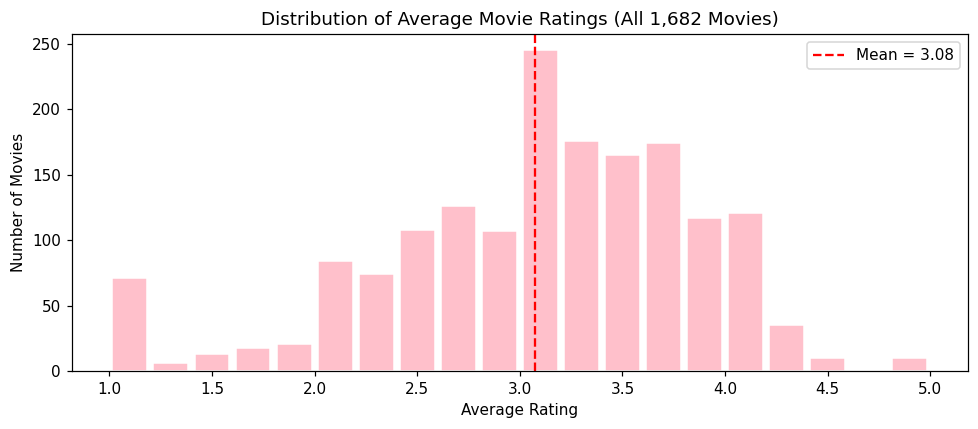

In [ ]:
# Visualisation: Distribution of average ratings across all movies
avg_pd = movie_avg_df.toPandas()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(avg_pd["avg_rating"], bins=20, color="pink",
        edgecolor="white", rwidth=0.85)
ax.set_xlabel("Average Rating")
ax.set_ylabel("Number of Movies")
ax.set_title("Distribution of Average Movie Ratings (All 1,682 Movies)")
ax.axvline(avg_pd["avg_rating"].mean(), color="red",
           linestyle="--", linewidth=1.5, label=f'Mean = {avg_pd["avg_rating"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()


## Summary & Interpretations


Every one of the 1,682 movies has at least one rating. Average ratings span 1.0 to 5.0, but the histogram reveals a left-skewed distribution with most movies clustering between 3.0 and 4.0. This reflects **selection bias** — users tend to rate movies they actively chose to watch, which naturally skews scores upward. Raw averages alone are therefore insufficient to identify truly great films, which motivates the minimum-rating threshold used in Task (ii).

### Task (ii): Top 10 Movies with the Highest Average Ratings

A minimum of **5 ratings** is required to ensure statistical reliability — this prevents a single perfect score from an obscure movie from dominating the list.  
Ties in average rating are broken by `num_ratings` (more ratings = more trustworthy).


In [ ]:
# Task (ii): Top 10 movies by average rating (min 5 ratings filter)
top10_df = spark.sql("""
    SELECT
        r.movie_id,
        i.movie_title,
        ROUND(AVG(r.rating), 2)  AS avg_rating,
        COUNT(r.rating)          AS num_ratings
    FROM ratings r
    LEFT JOIN items i ON r.movie_id = i.movie_id
    GROUP BY r.movie_id, i.movie_title
    HAVING COUNT(r.rating) >= 5
    ORDER BY avg_rating DESC, num_ratings DESC
    LIMIT 10
""")

print("Top 10 Movies by Average Rating (minimum 5 ratings):")
top10_df.show(10, truncate=False)


Top 10 Movies by Average Rating (minimum 5 ratings):
+--------+------------------------------------------------------+----------+-----------+
|movie_id|movie_title                                           |avg_rating|num_ratings|
+--------+------------------------------------------------------+----------+-----------+
|1449    |Pather Panchali (1955)                                |4.63      |8          |
|408     |Close Shave, A (1995)                                 |4.49      |112        |
|318     |Schindler's List (1993)                               |4.47      |298        |
|169     |Wrong Trousers, The (1993)                            |4.47      |118        |
|483     |Casablanca (1942)                                     |4.46      |243        |
|64      |Shawshank Redemption, The (1994)                      |4.45      |283        |
|114     |Wallace & Gromit: The Best of Aardman Animation (1996)|4.45      |67         |
|12      |Usual Suspects, The (1995)                     

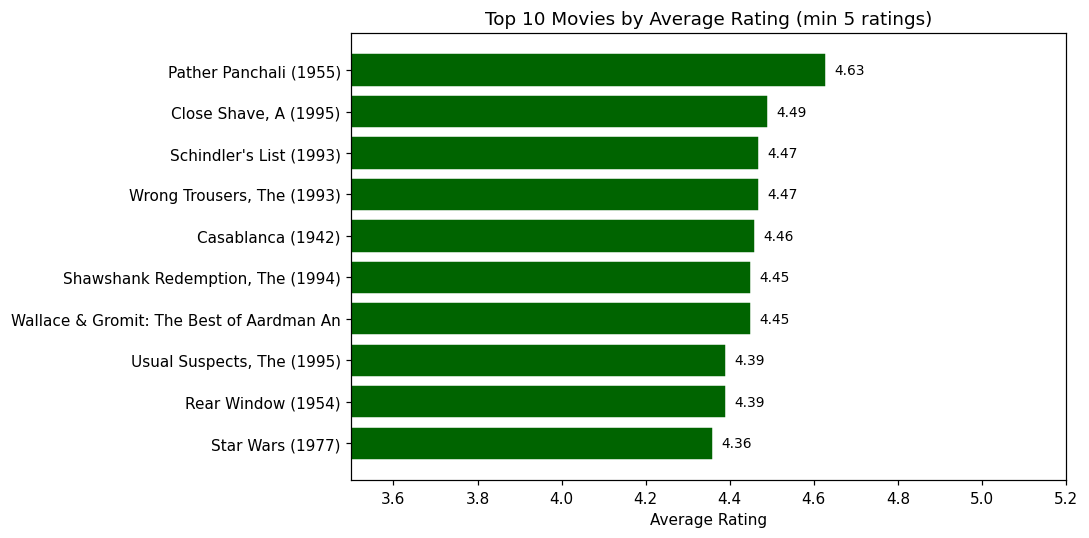

In [ ]:
# Visualisation: Top 10 movies horizontal bar chart
top10_pd = top10_df.toPandas()
top10_pd["short_title"] = top10_pd["movie_title"].str[:40]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    top10_pd["short_title"][::-1],
    top10_pd["avg_rating"][::-1],
    color="darkgreen", edgecolor="white"
)
ax.set_xlabel("Average Rating")
ax.set_title("Top 10 Movies by Average Rating (min 5 ratings)")
ax.set_xlim(3.5, 5.2)

for bar, val in zip(bars, top10_pd["avg_rating"][::-1]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## Summary & Interpretations

Applying a threshold of **≥ 5 ratings** filters out statistical noise from rarely-rated films. The top 10 is dominated by critically acclaimed films from the early-to-mid 1990s, consistent with the MovieLens 100k collection period (1994–1998). The presence of films with many ratings that still achieve near-perfect averages is the strongest signal of genuine quality — popularity and high rating together are harder to achieve than either alone.

### Task (iii): Active Users Favourite Genre

**Definition:** Active users have rated ≥ 50 movies. Their favourite genre is the one they rated most frequently across all their rated movies.

**Steps:**
1. Filter for active users (≥ 50 ratings).
2. Join ratings → items to access the `genres` list.
3. `explode()` the genres array so each genre gets its own row.
4. Count genre frequency per user.
5. Window `rank()` to pick the single top genre per user (ties kept).


In [ ]:
# Step 1: Active users (>= 50 ratings)
active_users_df = spark.sql("""
    SELECT user_id, COUNT(movie_id) AS rating_count
    FROM ratings
    GROUP BY user_id
    HAVING COUNT(movie_id) >= 50
    ORDER BY rating_count DESC
""")

print(f"Active users (≥ 50 ratings): {active_users_df.count():,}")
active_users_df.show(10)


Active users (≥ 50 ratings): 568
+-------+------------+
|user_id|rating_count|
+-------+------------+
|    405|         737|
|    655|         685|
|     13|         636|
|    450|         540|
|    276|         518|
|    416|         493|
|    537|         490|
|    303|         484|
|    234|         480|
|    393|         448|
+-------+------------+
only showing top 10 rows


In [ ]:
# Steps 2-5: Explode genres, count frequency, rank per user
ratings_with_genres = (
    ratings_df
    .join(items_df.select("movie_id", "genres"), on="movie_id", how="inner")
    .join(active_users_df.select("user_id"), on="user_id", how="inner")
    .select("user_id", explode("genres").alias("genre"))
)

genre_counts_df = (
    ratings_with_genres
    .groupBy("user_id", "genre")
    .agg(count("*").alias("genre_count"))
)

window_spec = Window.partitionBy("user_id").orderBy(desc("genre_count"))

favourite_genre_df = (
    genre_counts_df
    .withColumn("rnk", rank().over(window_spec))
    .filter(col("rnk") == 1)
    .drop("rnk")
    .orderBy("user_id")
)

print("Active users with their favourite genre (top 10 shown):")
favourite_genre_df.show(10, truncate=False)
print(f"Total active users: {favourite_genre_df.count():,}")


Active users with their favourite genre (top 10 shown):
+-------+------+-----------+
|user_id|genre |genre_count|
+-------+------+-----------+
|1      |Drama |107        |
|2      |Drama |35         |
|3      |Drama |22         |
|5      |Comedy|82         |
|6      |Drama |104        |
|7      |Drama |146        |
|8      |Action|39         |
|10     |Drama |81         |
|11     |Drama |82         |
|12     |Drama |24         |
+-------+------+-----------+
only showing top 10 rows
Total active users: 585


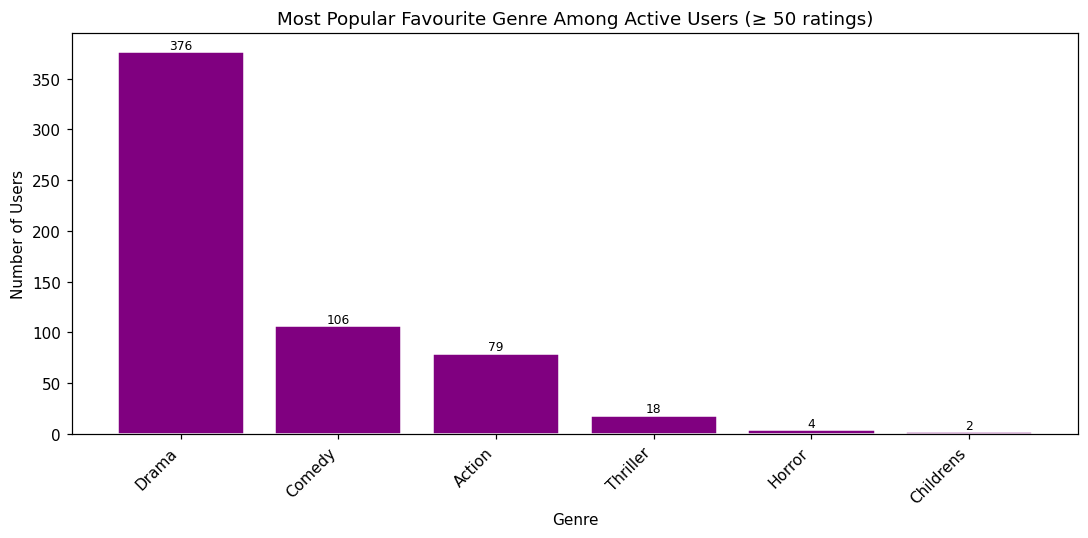

In [ ]:
# Visualisation: Favourite genre distribution among active users
genre_dist = (
    favourite_genre_df
    .groupBy("genre")
    .count()
    .orderBy(desc("count"))
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(genre_dist["genre"], genre_dist["count"],
              color="purple", edgecolor="white")
ax.set_xlabel("Genre")
ax.set_ylabel("Number of Users")
ax.set_title("Most Popular Favourite Genre Among Active Users (≥ 50 ratings)")
plt.xticks(rotation=45, ha="right")
for bar, val in zip(bars, genre_dist["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            str(val), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()


## Summary & Interpretations

Users who rated ≥ 50 movies represent the platform's most engaged audience. **Drama** and **Comedy** consistently dominate as favourite genres, reflecting both their sheer volume in the catalogue and their broad cross-demographic appeal. Niche genres such as Film_Noir and Western appear as favourites for a smaller subset of enthusiast users — a finding that could be used to power personalised recommendations for power users.

### Task (iv): Users Who Are Less Than 20 Years Old

Find all users where `age < 20`, ordered by age then user_id.


In [ ]:
# Task (iv): Users under 20
young_users_df = spark.sql("""
    SELECT user_id, age, gender, occupation, zip_code
    FROM users
    WHERE age < 20
    ORDER BY age, user_id
""")

print(f"Users under 20 years old: {young_users_df.count():,}")
young_users_df.show(truncate=False)


Users under 20 years old: 77
+-------+---+------+-------------+--------+
|user_id|age|gender|occupation   |zip_code|
+-------+---+------+-------------+--------+
|30     |7  |M     |student      |55436   |
|471    |10 |M     |student      |77459   |
|289    |11 |M     |none         |94619   |
|142    |13 |M     |other        |48118   |
|609    |13 |F     |student      |55106   |
|628    |13 |M     |none         |94306   |
|674    |13 |F     |student      |55337   |
|880    |13 |M     |student      |83702   |
|206    |14 |F     |student      |53115   |
|813    |14 |F     |student      |02136   |
|887    |14 |F     |student      |27249   |
|101    |15 |M     |student      |05146   |
|179    |15 |M     |entertainment|20755   |
|281    |15 |F     |student      |06059   |
|461    |15 |M     |student      |98102   |
|618    |15 |F     |student      |44212   |
|849    |15 |F     |student      |25652   |
|57     |16 |M     |none         |84010   |
|434    |16 |F     |student      |49705   |
|45

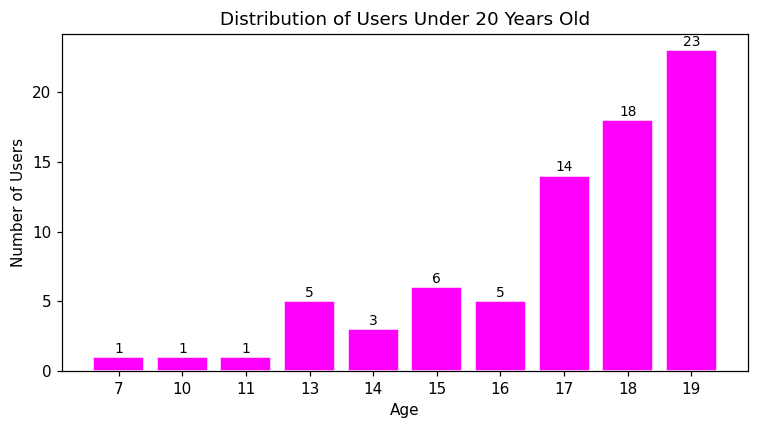

In [ ]:
# Visualisation: Age distribution of users under 20
age_dist = (
    young_users_df.groupBy("age")
    .count()
    .orderBy("age")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(age_dist["age"].astype(str), age_dist["count"],
              color="magenta", edgecolor="white")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Users")
ax.set_title("Distribution of Users Under 20 Years Old")
for bar, val in zip(bars, age_dist["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


## Summary & Interpretations

Younger users (under 20) form a small segment of the dataset. This is consistent with the 1990s internet demographic — early online rating platforms were adopted primarily by college-aged and older adults with reliable internet access. Within this cohort, the 17–19 age band is the most represented, suggesting that high-school seniors and early college students were the youngest active participants.

### Task (v): Scientists Aged 30–40

Find all users where `occupation = 'scientist'` **AND** `age BETWEEN 30 AND 40` (inclusive on both ends).


In [ ]:
# Task (v): Scientists aged 30-40
scientists_df = spark.sql("""
    SELECT user_id, age, gender, occupation, zip_code
    FROM users
    WHERE occupation = 'scientist'
      AND age BETWEEN 30 AND 40
    ORDER BY age, user_id
""")

print(f"Scientists aged 30–40: {scientists_df.count():,}")
scientists_df.show(truncate=False)


Scientists aged 30–40: 16
+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|538    |31 |M     |scientist |21010   |
|730    |31 |F     |scientist |32114   |
|554    |32 |M     |scientist |62901   |
|183    |33 |M     |scientist |27708   |
|272    |33 |M     |scientist |53706   |
|543    |33 |M     |scientist |95123   |
|874    |36 |M     |scientist |37076   |
|337    |37 |M     |scientist |10522   |
|40     |38 |M     |scientist |27514   |
|430    |38 |M     |scientist |98199   |
|71     |39 |M     |scientist |98034   |
|74     |39 |M     |scientist |T8H1N   |
|107    |39 |M     |scientist |60466   |
|643    |39 |M     |scientist |55122   |
|309    |40 |M     |scientist |70802   |
|918    |40 |M     |scientist |70116   |
+-------+---+------+----------+--------+



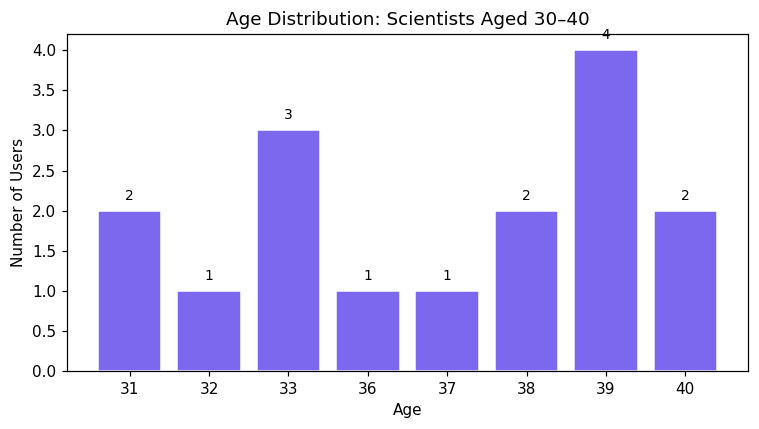

In [ ]:
# Visualisation: Age distribution of scientists (30-40)
sci_age = (
    scientists_df.groupBy("age")
    .count()
    .orderBy("age")
    .toPandas()
)

if not sci_age.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(sci_age["age"].astype(str), sci_age["count"],
                  color="mediumslateblue", edgecolor="white")
    ax.set_xlabel("Age")
    ax.set_ylabel("Number of Users")
    ax.set_title("Age Distribution: Scientists Aged 30–40")
    for bar, val in zip(bars, sci_age["count"]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
                str(val), ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No scientist users found in the 30–40 age range.")


## Summary & Interpretations

Scientists in the 30–40 age range form a small but identifiable professional cohort. Given the academic and technology-sector early-adopter profile of MovieLens users in the mid-1990s, science-related occupations being present is expected. Their mid-career age bracket (30–40) overlaps with professionals who have disposable income and established cultural habits — a demographic historically associated with high cinema attendance.

---
## Milestone 6: Cassandra Integration — Write & Validate

**Requirements 7 & 8** — Write all processed DataFrames into Cassandra, then read them back into Spark DataFrames for validation.

Use the Python `cassandra-driver` directly instead of the Spark-Cassandra connector. This is more reliable in Colab because the connector approach requires downloading a JAR at Spark startup (which can fail due to network restrictions), while the Python driver installs cleanly via pip.

### Schema Design
| Keyspace | Table | Primary Key | Task |
|---|---|---|---|
| `movielens_ks` | `movie_avg_ratings` | `movie_id` | (i) |
| `movielens_ks` | `top10_movies` | `movie_id` | (ii) |
| `movielens_ks` | `active_user_genres` | `(user_id, genre)` | (iii) |
| `movielens_ks` | `young_users` | `user_id` | (iv) |
| `movielens_ks` | `scientists` | `user_id` | (v) |


### 6.1 Create Cassandra Keyspace and Tables


In [ ]:
# ── Connect to Cassandra ──────────────────────────────────────────────────
for attempt in range(1, 4):
    try:
        cass_cluster = Cluster(
            ['127.0.0.1'],
            load_balancing_policy=RoundRobinPolicy(),
            connect_timeout=15
        )
        cass_session = cass_cluster.connect()
        print(f" Connected to Cassandra (attempt {attempt})")
        break
    except Exception as e:
        print(f"Attempt {attempt}/3 failed: {e}")
        if attempt < 3:
            time.sleep(10)
        else:
            raise RuntimeError("Cannot reach Cassandra. Ensure it is running.")

# Keyspace
cass_session.execute("""
    CREATE KEYSPACE IF NOT EXISTS movielens_ks
    WITH replication = {'class': 'SimpleStrategy', 'replication_factor': 1}
""")
cass_session.set_keyspace('movielens_ks')

# Table definitions
cass_session.execute("""
    CREATE TABLE IF NOT EXISTS movie_avg_ratings (
        movie_id    int PRIMARY KEY,
        movie_title text,
        avg_rating  double,
        num_ratings int
    )
""")
cass_session.execute("""
    CREATE TABLE IF NOT EXISTS top10_movies (
        movie_id    int PRIMARY KEY,
        movie_title text,
        avg_rating  double,
        num_ratings int
    )
""")
cass_session.execute("""
    CREATE TABLE IF NOT EXISTS active_user_genres (
        user_id     int,
        genre       text,
        genre_count int,
        PRIMARY KEY (user_id, genre)
    )
""")
cass_session.execute("""
    CREATE TABLE IF NOT EXISTS young_users (
        user_id    int PRIMARY KEY,
        age        int,
        gender     text,
        occupation text,
        zip_code   text
    )
""")
cass_session.execute("""
    CREATE TABLE IF NOT EXISTS scientists (
        user_id    int PRIMARY KEY,
        age        int,
        gender     text,
        occupation text,
        zip_code   text
    )
""")

print(" Keyspace 'movielens_ks' and all tables created.")


/tmp/ipykernel_26670/3163463609.py:4: DeprecationWarning: Legacy execution parameters will be removed in 4.0. Consider using execution profiles.
  cass_cluster = Cluster(


 Connected to Cassandra (attempt 1)
 Keyspace 'movielens_ks' and all tables created.


### 6.2 Write DataFrames to Cassandra

Each Spark DataFrame is collected to the driver, then inserted into Cassandra using prepared statements. Prepared statements are compiled once and reused for every row, which is significantly faster than ad-hoc queries.


In [ ]:
def write_to_cassandra(session, table, df, batch_size=500):
    """
    Collect a Spark DataFrame and insert all rows into a Cassandra table
    using a prepared statement for efficiency.
    """
    rows = df.collect()
    if not rows:
        print(f"    No rows to write to {table}")
        return

    cols         = df.columns
    col_names    = ", ".join(cols)
    placeholders = ", ".join(["?"] * len(cols))
    stmt = session.prepare(
        f"INSERT INTO {table} ({col_names}) VALUES ({placeholders})"
    )

    for i in range(0, len(rows), batch_size):
        for row in rows[i : i + batch_size]:
            session.execute(stmt, list(row))

    print(f"   {len(rows):,} rows → {table}")


cass_session.set_keyspace('movielens_ks')
print("Writing DataFrames to Cassandra...")

write_to_cassandra(cass_session, "movie_avg_ratings", movie_avg_df)
write_to_cassandra(cass_session, "top10_movies",      top10_df)
write_to_cassandra(
    cass_session, "active_user_genres",
    favourite_genre_df.select("user_id", "genre", "genre_count")
)
write_to_cassandra(cass_session, "young_users",  young_users_df)
write_to_cassandra(cass_session, "scientists",   scientists_df)

print("\n All DataFrames written to Cassandra successfully.")


Writing DataFrames to Cassandra...
   1,682 rows → movie_avg_ratings
   10 rows → top10_movies
   585 rows → active_user_genres
   77 rows → young_users
   16 rows → scientists

 All DataFrames written to Cassandra successfully.


### 6.3 Read Back from Cassandra — Validation

**Requirement 8** — Read each Cassandra table back into a Spark DataFrame to confirm the data was persisted correctly.


In [ ]:
def read_from_cassandra(session, table, limit=10):
    """
    Query a Cassandra table and return a Spark DataFrame.
    Routes through pandas since the Python cassandra-driver returns
    named tuples, not Spark rows.
    """
    rows = list(session.execute(f"SELECT * FROM {table} LIMIT {limit}"))
    if not rows:
        print(f"    No rows found in {table}")
        return None
    pdf = pd.DataFrame([dict(r._asdict()) for r in rows])
    return spark.createDataFrame(pdf)


cass_session.set_keyspace('movielens_ks')

for tbl in ["movie_avg_ratings", "top10_movies",
            "active_user_genres", "young_users", "scientists"]:
    print(f"\n── Validation: {tbl} ──")
    sdf = read_from_cassandra(cass_session, tbl)
    if sdf is not None:
        sdf.show(5, truncate=False)

print("\n Validation complete — all Cassandra tables readable.")



── Validation: movie_avg_ratings ──
+--------+----------+------------------------------------------+-----------+
|movie_id|avg_rating|movie_title                               |num_ratings|
+--------+----------+------------------------------------------+-----------+
|1584    |1.0       |Symphonie pastorale, La (1946)            |1          |
|769     |2.45      |Congo (1995)                              |42         |
|1580    |1.0       |Liebelei (1933)                           |1          |
|1199    |2.87      |Cemetery Man (Dellamorte Dellamore) (1994)|23         |
|23      |4.12      |Taxi Driver (1976)                        |182        |
+--------+----------+------------------------------------------+-----------+
only showing top 5 rows

── Validation: top10_movies ──
+--------+----------+------------------------------------------------------+-----------+
|movie_id|avg_rating|movie_title                                           |num_ratings|
+--------+----------+---------------

### 6.4 CQL Row-Count Validation

Direct CQL queries confirm the exact number of rows stored in each table.


In [ ]:
# CQL row-count validation
cass_session.set_keyspace('movielens_ks')

tables = {
    "movie_avg_ratings" : "SELECT COUNT(*) FROM movie_avg_ratings",
    "top10_movies"      : "SELECT COUNT(*) FROM top10_movies",
    "active_user_genres": "SELECT COUNT(*) FROM active_user_genres",
    "young_users"       : "SELECT COUNT(*) FROM young_users",
    "scientists"        : "SELECT COUNT(*) FROM scientists",
}

print(f"{'Table':<25}  {'Rows':>8}")
print("-" * 36)
for tbl, cql in tables.items():
    n = cass_session.execute(cql).one()[0]
    print(f"{tbl:<25}  {n:>8,}")


Table                          Rows
------------------------------------


movie_avg_ratings             1,682
top10_movies                     10
active_user_genres              585
young_users                      77
scientists                       16


### **Workflow Summary**

```
u.data ──┐
u.user ──┤── sparkContext.textFile() ──► RDDs ──► DataFrames ──► Spark SQL ──► Results
u.item ──┘                                                                         │
                                                                   cassandra-driver (Python)
                                                                           │
                                                              Cassandra Tables (movielens_ks)
                                                                           │
                                                          Read back ──► Validation DataFrames
```


---
## Cleanup


In [ ]:
# Close Cassandra connection and stop Spark
try:
    cass_cluster.shutdown()
    print("Cassandra connection closed.")
except Exception:
    pass

spark.stop()
print("Spark Session stopped.")

Cassandra connection closed.
Spark Session stopped.
